# Segmentacja

In [1]:
import random

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

Wczytujemy przygotowane przez nas klasy z lokalnego pakietu `coronary_analysis`.

In [2]:
from coronary_analysis.models.segmentation import CoronaryUNetCustom
from coronary_analysis.transforms import (
    get_train_transforms,
    get_val_transforms,
)
from coronary_analysis.datasets import (
    ArcadeSyntaxBinaryDataset,
    get_dca1_pairs,
)
from coronary_analysis.datasets import (
    get_fs_cad_pairs,
)
from coronary_analysis.datasets import DCA1FSCADDataset
from coronary_analysis.metrics import BCEDiceClDiceCriterion
from coronary_analysis.utils import show_image, plot_lines
from coronary_analysis.metrics import compute_dice_iou_metrics
from coronary_analysis.train import training_loop

Poniżej funkcja ustawia `seed` we wszystkich używanych bibliotekach, aby zapewnić powtarzalność wyników.

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [4]:
set_seed(42)

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [6]:
IMG_SIZE = 300

In [7]:
WEIGHT_DECAY = 1e-4

# model = CoronaryUNet(encoder_name="resnet18").to(device)
model = CoronaryUNetCustom(
    encoder_name="resnet18", encoder_weights=None, dropout=0.2
).to(device)
# model = CoronaryDeeplabV3Plus(encoder_name="resnet18").to(device)
# model = CoronaryUNetPP(encoder_name="resnet18").to(device)

#### ARCADE Pretrening

In [8]:
IMAGE_DIR = "raw_datasets/arcade/arcade/syntax"
BATCH_SIZE = 32

arcade_train_ds = ArcadeSyntaxBinaryDataset(
    root=IMAGE_DIR,
    split="train",
    transform=get_train_transforms(IMG_SIZE),
)
arcade_val_ds = ArcadeSyntaxBinaryDataset(
    root=IMAGE_DIR,
    split="val",
    transform=get_val_transforms(IMG_SIZE),
)

train_loader = DataLoader(
    arcade_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)
val_loader = DataLoader(
    arcade_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

loading annotations into memory...
Done (t=0.33s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


In [9]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-2,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=10,
)
criterion = BCEDiceClDiceCriterion(bce_weight=0.5, dice_weight=0.5, cldice_weight=0.0)

In [ ]:
history = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=50,
    scheduler=scheduler,
)

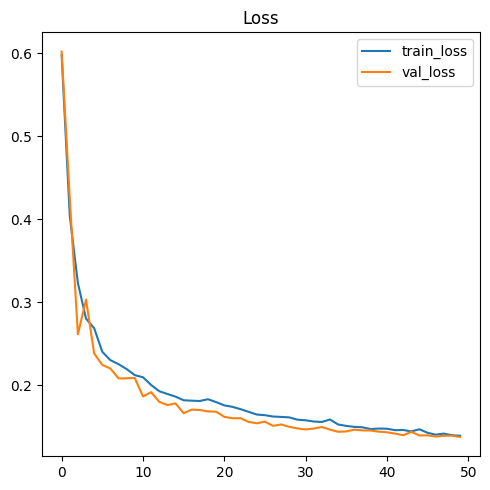

In [11]:
plot_lines(
    history,
    (["train_loss", "val_loss"], "Loss"),
)

In [12]:
if device.type == "cuda":
    torch.cuda.empty_cache()
elif device.type == "mps":
    torch.mps.empty_cache()

#### DCA1 Fine-tuning

Podział zbioru DCA1 na treningowy i walidacyjny. Używamy funkcji `train_test_split` z biblioteki `sklearn` do losowego podziału danych, zachowując 25% próbek w zbiorze walidacyjnym.

In [13]:
IMAGE_DIR_DCA1 = "raw_datasets/DCA1/Database_134_Angiograms"
dca1_pairs = get_dca1_pairs(IMAGE_DIR_DCA1)

dca1_train_pairs, dca1_val_pairs = train_test_split(
    dca1_pairs, test_size=0.25, random_state=42
)

In [14]:
IMAGE_DIR_FS_CAD = "raw_datasets/FS-CAD/FS-CAD"

fscad_pairs = get_fs_cad_pairs(IMAGE_DIR_FS_CAD)
fscad_train_pairs, fscad_val_pairs = train_test_split(
    fscad_pairs, test_size=0.25, random_state=42
)

In [15]:
BATCH_SIZE = 32

train_ds = DCA1FSCADDataset(
    dca1_image_dir=IMAGE_DIR_DCA1,
    fs_cad_image_dir=IMAGE_DIR_FS_CAD,
    dca1_pairs=dca1_train_pairs,
    fs_cad_pairs=fscad_train_pairs,
    transform=get_train_transforms(IMG_SIZE),
)
val_ds = DCA1FSCADDataset(
    dca1_image_dir=IMAGE_DIR_DCA1,
    fs_cad_image_dir=IMAGE_DIR_FS_CAD,
    dca1_pairs=dca1_val_pairs,
    fs_cad_pairs=fscad_val_pairs,
    transform=get_val_transforms(IMG_SIZE),
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=20,
)
# criterion = BCEDiceCriterion(bce_weight=0.5, dice_weight=0.5)
criterion = BCEDiceClDiceCriterion(bce_weight=0.3, dice_weight=0.7, cldice_weight=0.2)

Finetuning na zbiorze DCA1

In [ ]:
history = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=100,
    scheduler=scheduler,
    metrics_function=compute_dice_iou_metrics,
    early_stopping_patience=40,
)

In [18]:
# TODO: threshold tuning

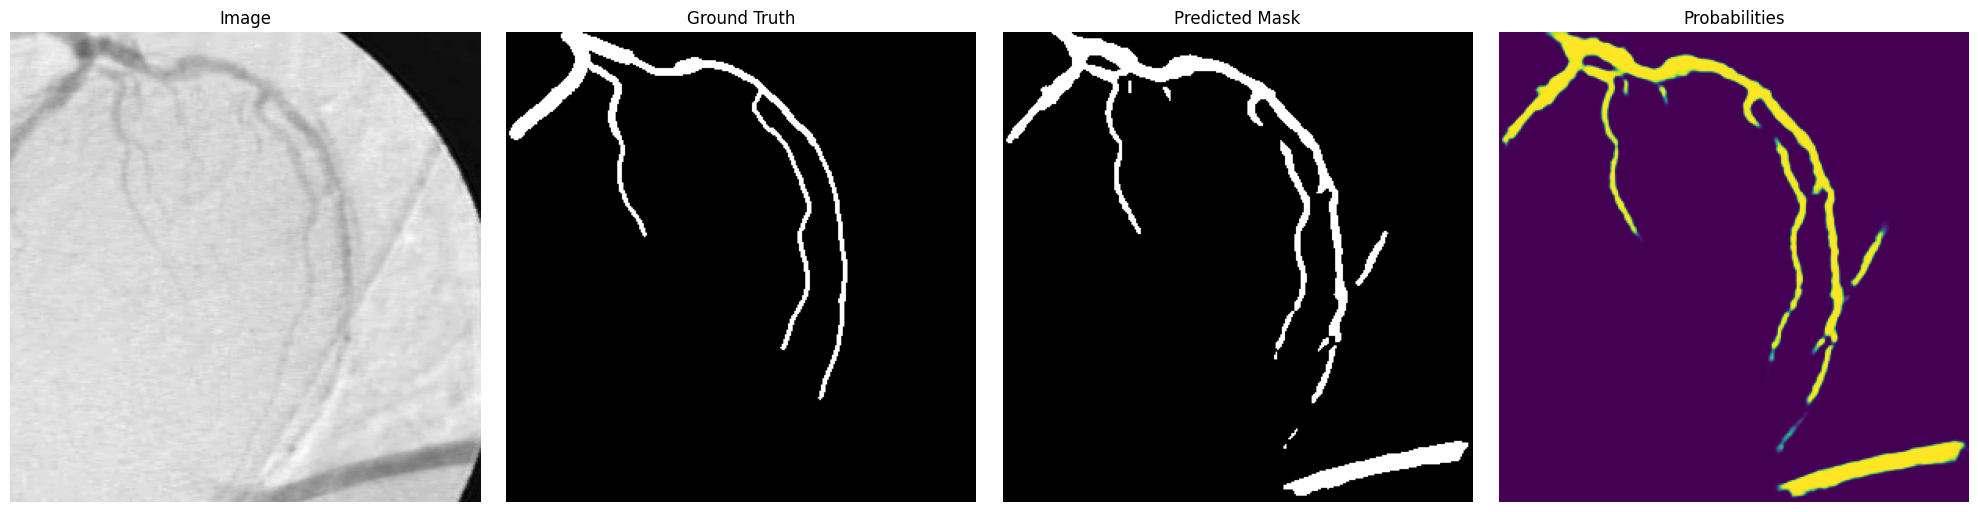

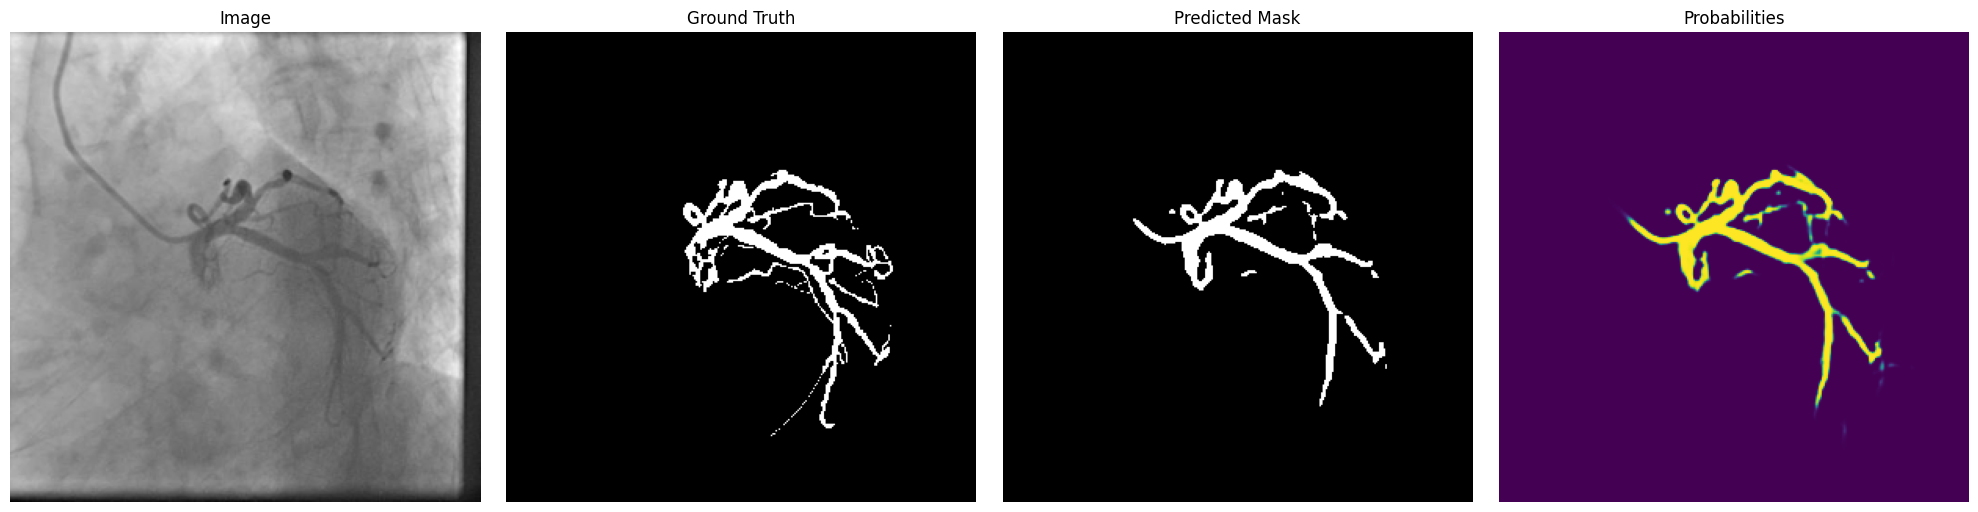

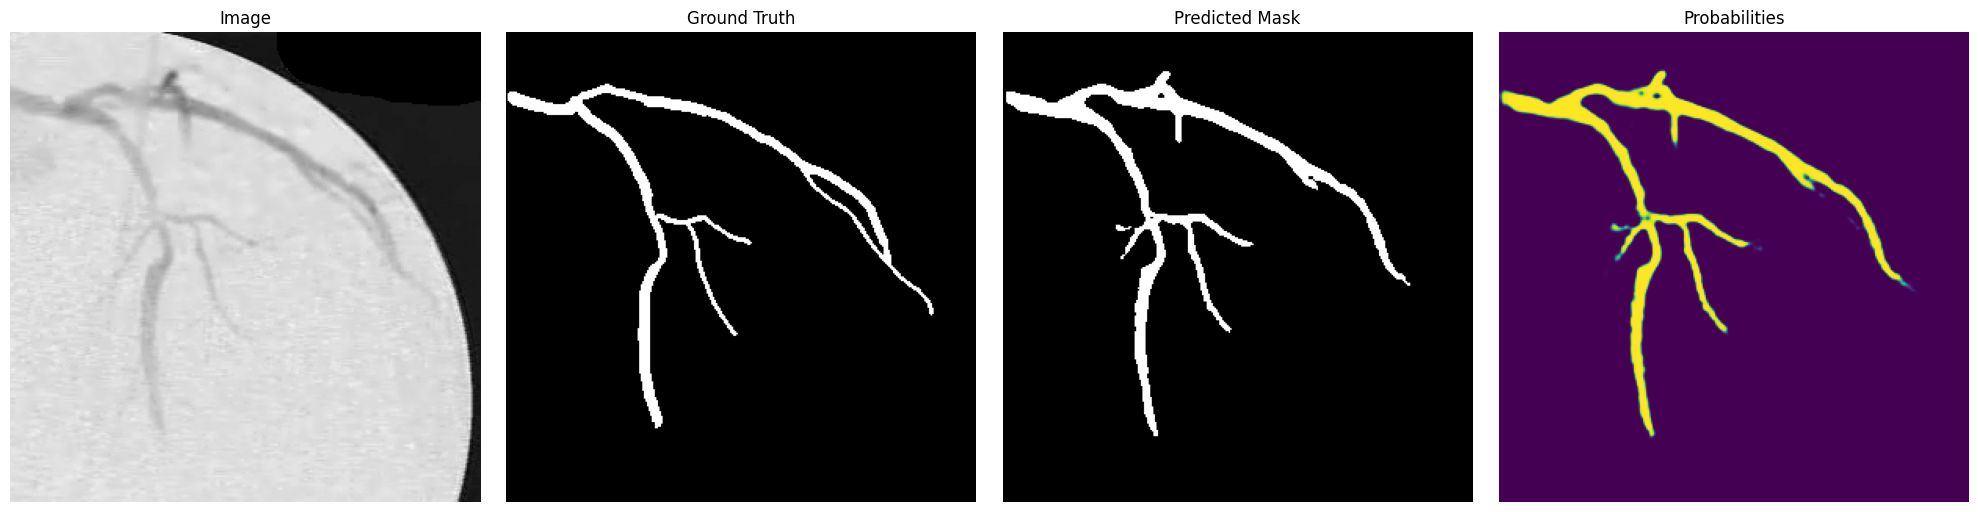

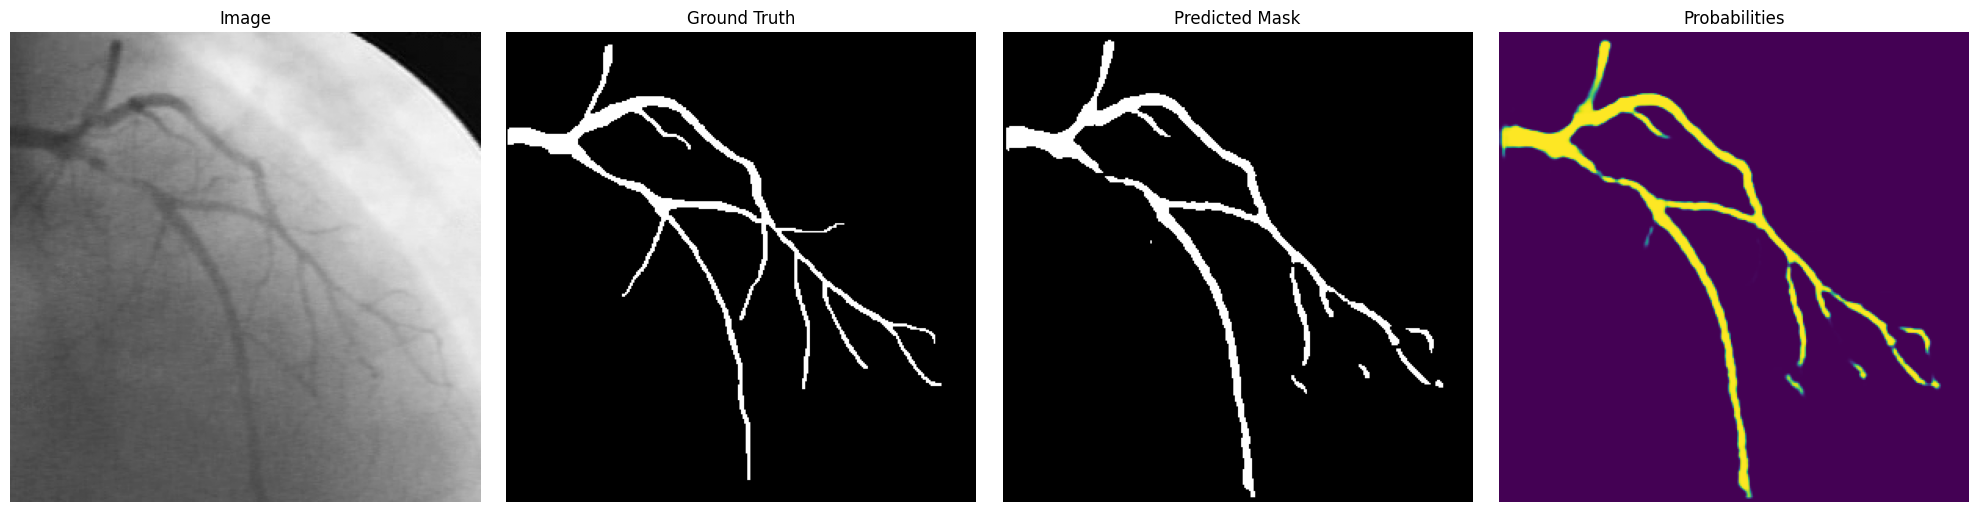

In [19]:
model.eval()

with torch.no_grad():
    val_loader_iter = iter(val_loader)
    for i in range(5 // BATCH_SIZE + 1):
        images, masks = next(val_loader_iter)
        images = images.to(device)
        masks = masks.to(device)

        probs = model.predict_proba(images)
        preds = (probs > 0.5).float()

        for j in range(min(4, images.size(0))):
            show_image(
                images[j, 0].cpu().numpy(),
                masks[j, 0].cpu().numpy(),
                preds[j, 0].cpu().numpy(),
                probs[j, 0].cpu().numpy(),
                titles=["Image", "Ground Truth", "Predicted Mask", "Probabilities"],
                cmap=["gray", "gray", "gray", None],
            )

Ostateczna walidacja modelu na zbiorze DCA1.

In [20]:
# val metrics

with torch.no_grad():
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0
    total_samples = 0

    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks).item()
        metrics = compute_dice_iou_metrics(logits, masks)

        batch_size = images.size(0)
        val_loss += loss * batch_size
        val_dice += metrics["dice"] * batch_size
        val_iou += metrics["iou"] * batch_size
        total_samples += batch_size

    val_loss /= total_samples
    val_dice /= total_samples
    val_iou /= total_samples

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Dice Coefficient: {val_dice:.4f}")
    print(f"Validation IoU: {val_iou:.4f}")

Validation Loss: 0.2300
Validation Dice Coefficient: 0.7799
Validation IoU: 0.6393


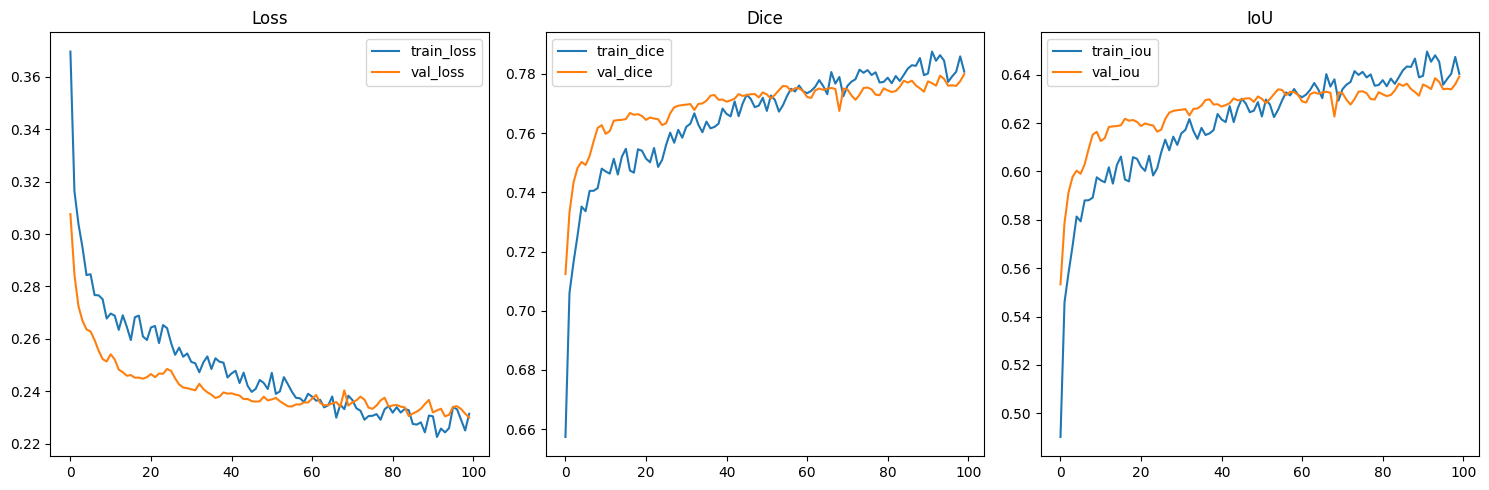

In [21]:
plot_lines(
    history,
    (["train_loss", "val_loss"], "Loss"),
    (["train_dice", "val_dice"], "Dice"),
    (["train_iou", "val_iou"], "IoU"),
)

In [22]:
import os

if not os.path.exists("../models"):
    os.makedirs("../models")

torch.save(model.state_dict(), "../models/best_coronary_unet.pth")

#### Unseen examples from ARCADE

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


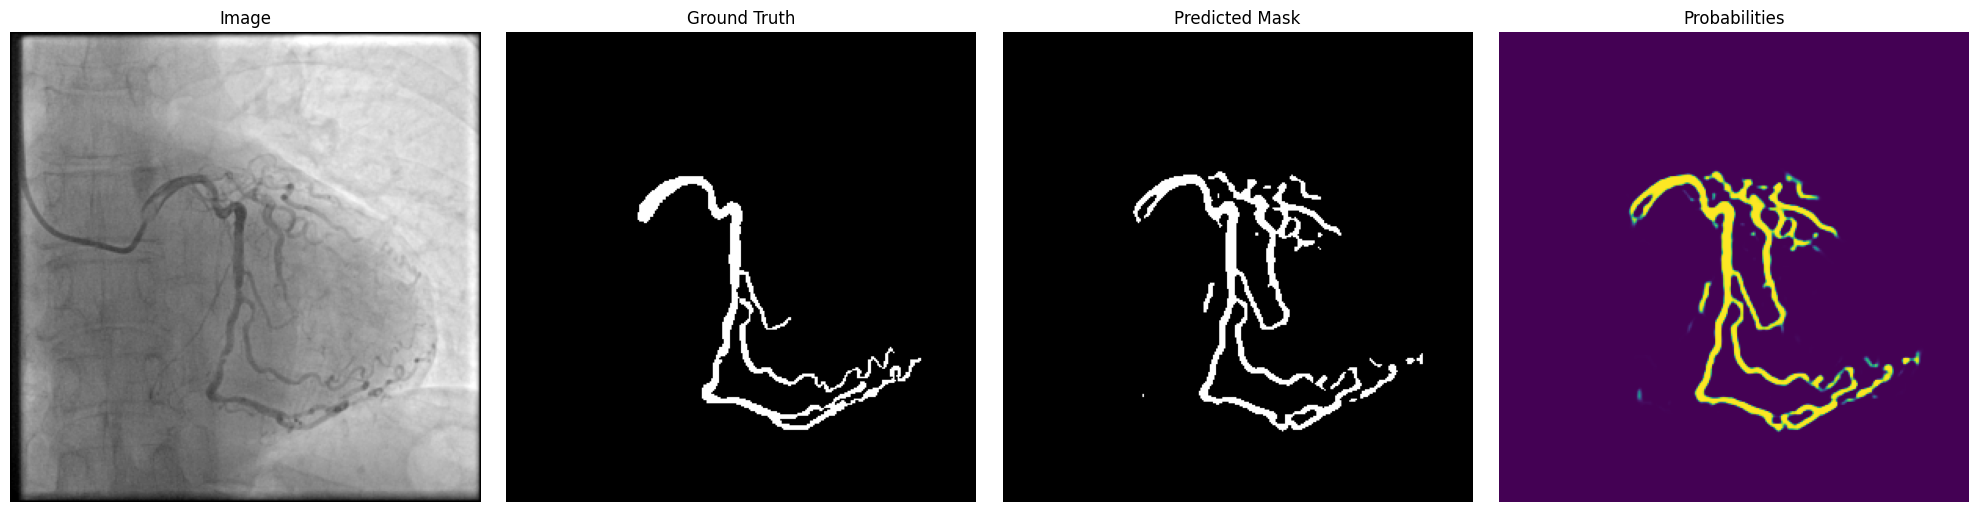

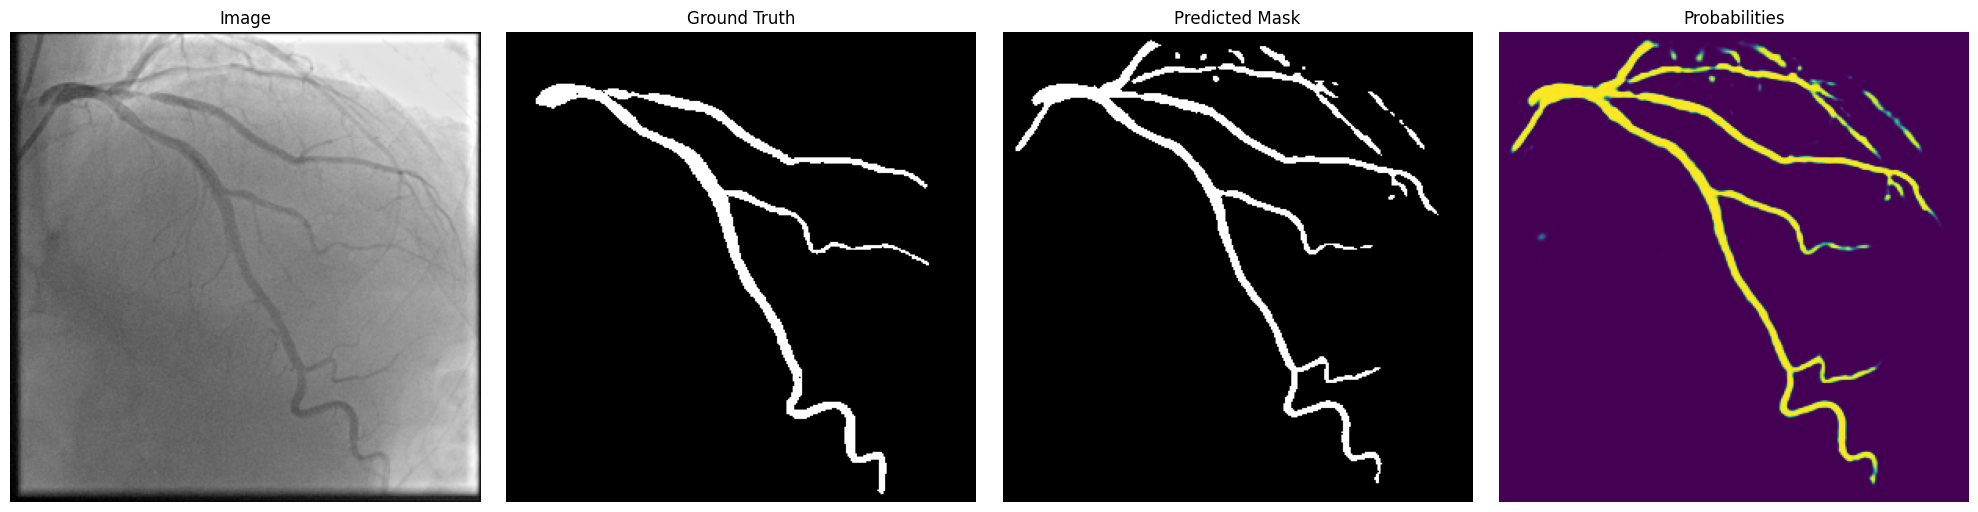

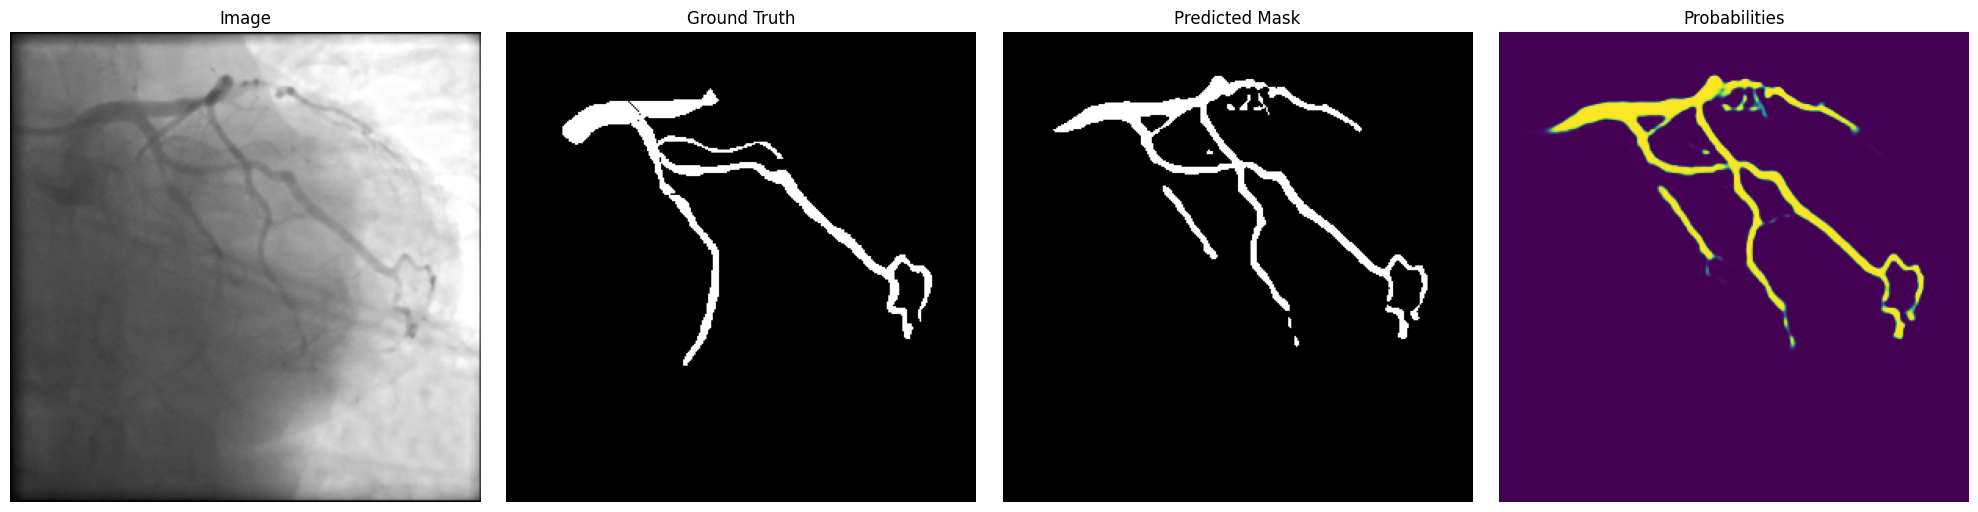

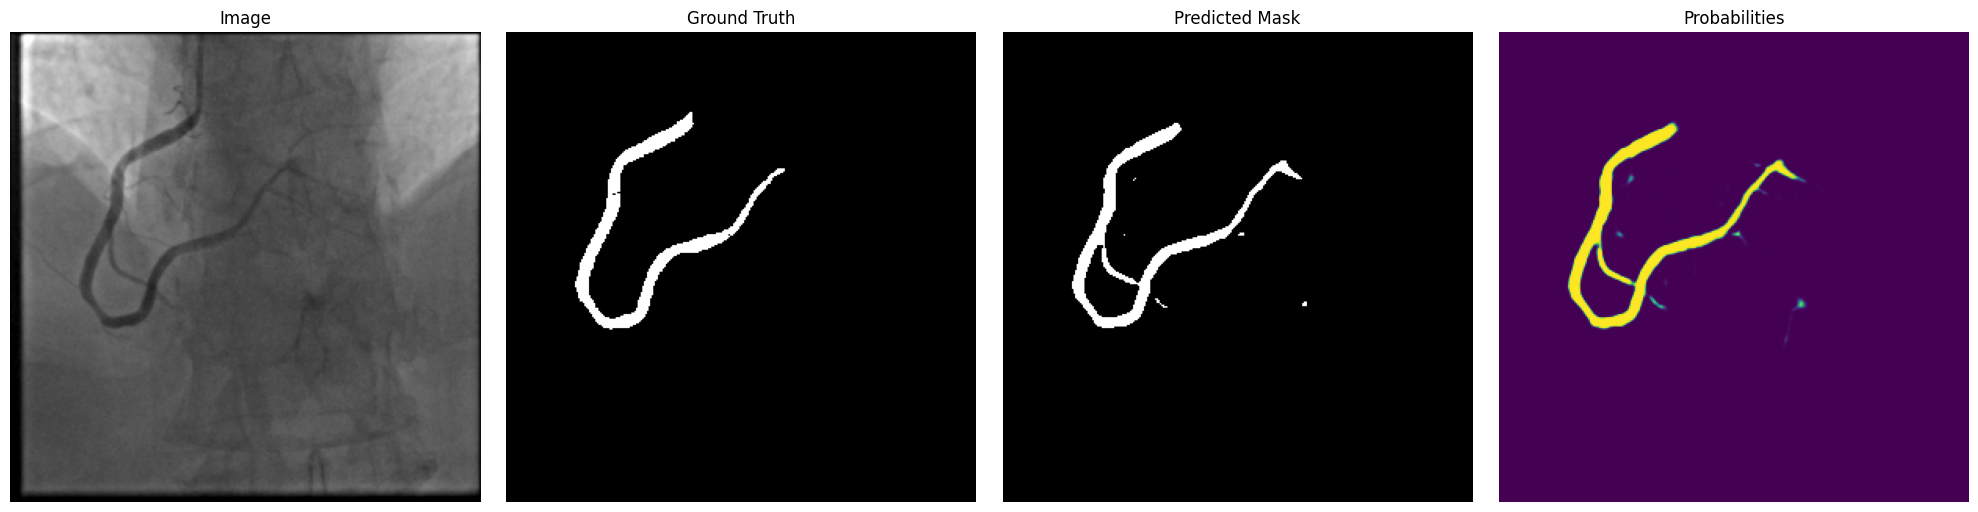

In [23]:
test_arcade = ArcadeSyntaxBinaryDataset(
    root="raw_datasets/arcade/arcade/syntax",
    split="test",
    transform=get_val_transforms(IMG_SIZE),
)

test_loader = DataLoader(
    test_arcade,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

model.eval()

with torch.no_grad():
    test_loader_iter = iter(test_loader)
    for i in range(5 // BATCH_SIZE + 1):
        images, masks = next(test_loader_iter)
        images = images.to(device)
        masks = masks.to(device)

        probs = model.predict_proba(images)
        preds = (probs > 0.5).float()

        for j in range(min(4, images.size(0))):
            show_image(
                images[j, 0].cpu().numpy(),
                masks[j, 0].cpu().numpy(),
                preds[j, 0].cpu().numpy(),
                probs[j, 0].cpu().numpy(),
                titles=["Image", "Ground Truth", "Predicted Mask", "Probabilities"],
                cmap=["gray", "gray", "gray", None],
            )